<a href="https://colab.research.google.com/github/javier-jaime/Tool-Crib/blob/master/Neuro-Symbolic-AI/Neuro_Symbolic_Programming_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neuro-Symbolic Programming Demo

 This Demo will introduce the different mechanisms and thought processes associated with neuro-symbolic programming, using kaggle Red and White Wine dataset (https://www.kaggle.com/datasets/numberswithkartik/red-white-wine-dataset). This dataset consists of 12 features describing different wine characteristics and a binary label representing whether said wine is a red or white wine.

 This demo is based on code from: Neuro-Symbolic AI, by Alexiei Dingli & David Farrugia (https://github.com/PacktPublishing/Neuro-Symbolic-AI) and will use the Logic Tensor Network (LTN) library based on PyTorch (https://arxiv.org/pdf/1606.04422).

### Import the required libraries

In [1]:
#  install Logic Tensor Network (LTN) PyTorch library
!pip install LTNtorch

In [2]:
import torch
import ltn
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from google.colab import drive
from google.colab import files

## Data Preparation

In [3]:
# Mount Google Drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Read the wine dataset from CSV in Google Drive to Pandas Data Frame
df = pd.read_csv('drive/MyDrive/Colab_Notebooks/Datasets/wine_dataset.csv')
print(df.shape)

# Convert the main independent variable style to binary
df['style'] = np.where(df['style'] == 'red', True, False)

# Drop the second independent variable quality
df.drop('quality', axis=1, inplace=True)

#  Shuffle the dataset
df = df.sample(frac=1)

# Split the dataset into features and labels
features = df.drop('style', axis=1).values
# Standardize the features to have a zero mean and unit variance
features = (features - features.mean()) / features.std()
# Convert features and labels to PyTorch tensors
features = torch.tensor(features).to(dtype=torch.float32)
labels = torch.tensor(df['style'].values).to(dtype=torch.float32)

(6497, 13)


## Helper Functions

In [5]:
# we define predicate A
class ModelA(torch.nn.Module):
    def __init__(self):
        super(ModelA, self).__init__()
        self.sigmoid = torch.nn.Sigmoid()

        self.layer1 = torch.nn.Linear(11, 64)
        self.layer2 = torch.nn.Linear(64, 64)
        self.layer3 = torch.nn.Linear(64, 1)

        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=0.1)


    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        return self.sigmoid(self.layer3(x))

In [6]:
# this is a standard PyTorch DataLoader to load the dataset for the training and testing of the model
class DataLoader(object):
    def __init__(self, data, labels, batch_size=1, shuffle=True):
        self.data = data
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(self.data.shape[0] / self.batch_size))

    def __iter__(self):
        n = self.data.shape[0]
        idx_pos = np.where(self.labels == 1)[0]
        idx_neg = np.where(self.labels == 0)[0]
        np.random.shuffle(idx_pos)
        np.random.shuffle(idx_neg)

        for start_idx in range(0, n, self.batch_size):
            end_idx = min(start_idx + self.batch_size, n)

            # Get one positive and one negative sample for each batch
            pos_batch_size = min(self.batch_size // 2, len(idx_pos))
            neg_batch_size = self.batch_size - pos_batch_size
            pos_idx = idx_pos[:pos_batch_size]
            neg_idx = np.random.choice(idx_neg, size=neg_batch_size, replace=False)
            idx = np.concatenate([pos_idx, neg_idx])
            np.random.shuffle(idx)

            data = self.data[idx]
            labels = self.labels[idx]

            yield data, labels


# define metrics for evaluation of the model

# it computes the overall satisfaction level on the knowledge base using the given data loader (train or test)
def compute_sat_level(loader):
    mean_sat = 0
    for data, labels in loader:
        # get our positive samples
        x_A = ltn.Variable("x_A", data[torch.nonzero(labels)])
        # get our negative samples
        x_not_A = ltn.Variable("x_not_A",
                               data[torch.nonzero(torch.logical_not(labels))])

        # get the mean SAT of both sample types
        mean_sat += SatAgg(
            Forall(x_A, A(x_A)),
            Forall(x_not_A, Not(A(x_not_A)))
        )

    # get the mean SAT over all samples
    mean_sat /= len(loader)
    return mean_sat

# it computes the overall accuracy of the predictions of the trained model using the given data loader
# (train or test)
def compute_accuracy(loader):
    mean_accuracy = 0.0
    # iterate over our data samples
    for data, labels in loader:
        # get the predictions for the given samples
        predictions = A.model(data).detach().numpy()

        # convert the predictions to a binary classification (i.e., 0 or 1)
        predictions = np.where(predictions > 0.5, 1., 0.).flatten()

        # compute the accuracy_score
        mean_accuracy += accuracy_score(labels, predictions)
    # get the mean accuracy
    return mean_accuracy / len(loader)


# it computes the overall accuracy of the predictions of the trained model using the given data loader
# (train or test)
def compute_f1(loader):
    mean_accuracy = 0.0
    # iterate over our data samples
    for data, labels in loader:
        # get the predictions for the given samples
        predictions = A.model(data).detach().numpy()

        # convert the predictions to a binary classification (i.e., 0 or 1)
        predictions = np.where(predictions > 0.5, 1., 0.).flatten()

        # compute the accuracy_score
        mean_accuracy += f1_score(labels, predictions)
    # get the mean accuracy
    return mean_accuracy / len(loader)

## Modelling

The first objective is, to correctly represent our dataset as logical formulas. In LTNs, we typically represent these logical formulas as axioms. So, we need to extract the knowledge base (axioms) from the dataset to create our NN, for this, we define our predicate, the connectives, and the quantifiers.


- Predicate: In LTNs, an algorithm maps a high-dimensional vector space to a specific label set. Our binary classification task requires the predicate to map to either 0 or 1.

- Connective: A logical connective such as a conjunction (AND), disjunction (OR), negation (NOT), or implication (IMPLIES).

- Quantifier: Describes how many (i.e., the quantity) samples satisfy the predicate. The two main quantifiers are Universal (indicates the for all amount, represented by the symbol ∀) and Existential (indicates the exists quantity, represented by the symbol ∃).

In [7]:
A = ltn.Predicate(ModelA())

# we define the connectives, quantifiers, and the SatAgg
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
SatAgg = ltn.fuzzy_ops.SatAgg()

# create training and testing dataloader, batch_size = 64
train_loader = DataLoader(features[:91], labels[:91], 64, True)
test_loader = DataLoader(features[91:], labels[91:], 64, False)

optimizer = torch.optim.Adam(A.parameters(), lr=0.001)

In [8]:
# Batch the data for a given number of epochs (iterations)
EPOCHS: int = 100
train_sat_list, test_sat_list, train_acc_list, test_acc_list, epoch_list = [], [], [], [], []

for epoch in range(EPOCHS):
    # reset the training loss for every epoch
    train_loss = 0.0

    # start batching the data
    for batch_idx, (data, labels) in enumerate(train_loader):
        optimizer.zero_grad()

        # we ground the variables with current batch data
        x_A = ltn.Variable("x_A", data[torch.nonzero(labels)]) # positive examples
        x_not_A = ltn.Variable("x_not_A", data[torch.nonzero(torch.logical_not(labels))]) # negative examples

        # compute SAT level
        sat_agg = SatAgg(
            Forall(x_A, A(x_A)),
            Forall(x_not_A, Not(A(x_not_A)))
        )

        # compute loss and perform back-propagation
        loss = 1. - sat_agg
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # monitor the training loss
    train_loss = train_loss / len(train_loader)

    # we print metrics every 20 epochs of training
    if epoch % 20 == 0:
        train_sat = compute_sat_level(train_loader).item()
        test_sat = compute_sat_level(test_loader).item()
        train_acc = compute_accuracy(train_loader)
        test_acc = compute_accuracy(test_loader)

        epoch_list.append(epoch)
        train_sat_list.append(train_sat)
        test_sat_list.append(test_sat)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(" epoch %d | loss %.4f | Train Sat %.3f | Test Sat %.3f | Train Acc %.3f | Test Acc %.3f | Train F1 %.3f | Test F1 %.3f"
              %(epoch, train_loss, train_sat, test_sat, train_acc, test_acc, compute_f1(train_loader), compute_f1(test_loader)))

 epoch 0 | loss 0.4937 | Train Sat 0.515 | Test Sat 0.514 | Train Acc 0.641 | Test Acc 0.500 | Train F1 0.000 | Test F1 0.004
 epoch 20 | loss 0.3706 | Train Sat 0.634 | Test Sat 0.629 | Train Acc 0.883 | Test Acc 0.858 | Train F1 0.876 | Test F1 0.830
 epoch 40 | loss 0.2822 | Train Sat 0.715 | Test Sat 0.687 | Train Acc 0.914 | Test Acc 0.863 | Train F1 0.884 | Test F1 0.884
 epoch 60 | loss 0.2792 | Train Sat 0.724 | Test Sat 0.735 | Train Acc 0.914 | Test Acc 0.943 | Train F1 0.882 | Test F1 0.962
 epoch 80 | loss 0.2728 | Train Sat 0.736 | Test Sat 0.722 | Train Acc 0.930 | Test Acc 0.898 | Train F1 0.913 | Test F1 0.852


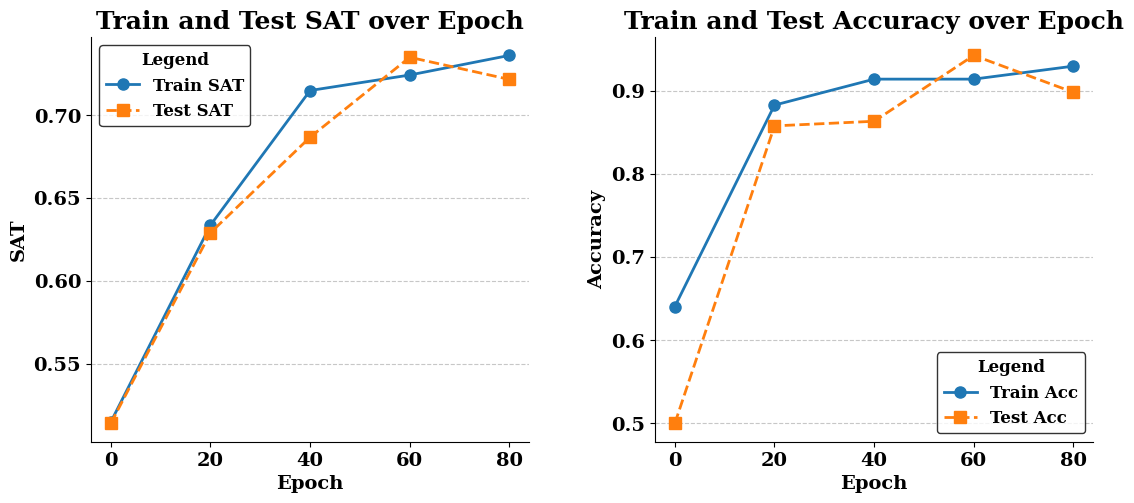

In [9]:
# Plot the Results

import matplotlib.pyplot as plt
%matplotlib inline

font = {'family': 'serif', 'weight': 'bold', 'size': 14}
plt.rc('font', **font)

# Create subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))


# Plot 1: Train and Test SAT over Epoch
axs[0].plot(epoch_list, train_sat_list, label='Train SAT', linewidth=2, linestyle='-', marker='o', markersize=8, color='#1f77b4')
axs[0].plot(epoch_list, test_sat_list, label='Test SAT', linewidth=2, linestyle='--', marker='s', markersize=8, color='#ff7f0e')
axs[0].set_xlabel('Epoch', fontsize=14, fontweight='bold', fontfamily='serif')
axs[0].set_ylabel('SAT', fontsize=14, fontweight='bold', fontfamily='serif')
axs[0].set_title('Train and Test SAT over Epoch', fontsize=18, fontweight='bold', fontfamily='serif')
axs[0].legend(loc='best', fontsize=12, framealpha=0.8, title_fontsize=12, title='Legend', edgecolor='black')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)

# Plot 2: Train and Test Accuracy over Epoch
axs[1].plot(epoch_list, train_acc_list, label='Train Acc', linewidth=2, linestyle='-', marker='o', markersize=8, color='#1f77b4')
axs[1].plot(epoch_list, test_acc_list, label='Test Acc', linewidth=2, linestyle='--', marker='s', markersize=8, color='#ff7f0e')
axs[1].set_xlabel('Epoch', fontsize=14, fontweight='bold', fontfamily='serif')
axs[1].set_ylabel('Accuracy', fontsize=14, fontweight='bold', fontfamily='serif')
axs[1].set_title('Train and Test Accuracy over Epoch', fontsize=18, fontweight='bold', fontfamily='serif')
axs[1].legend(loc='best', fontsize=12, framealpha=0.8, title_fontsize=12, title='Legend', edgecolor='black')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)

# Adjust spacing between subplots
fig.tight_layout(pad=3.0)

plt.show()

## Analyzing the results

Monitoring the training process, the SAT and accuracy scores improve with every epoch. The NSAI architecture generalizes quickly and arguably better, resulting in a rapid training process. Considering that our training dataset consists of only 91 samples, this highlights the power of NSAI to achieve high performance with small data.

Another benefit of LTNs is their high transparency. The LTN training process involves translating first-order logic to tensor embeddings. We start off with logical relationships between variables and predicates. Then, we use quantifiers over the variables and  predicates (returning either True or False) and transform them into multi-dimensional vectors (using tensor operations). As such, the resulting tensors embed the logical relationships. We can trace the entire process for every prediction by examining the tensor operations and logical connections.



---



---



## Solution 2 – prediction stacking

In [20]:
# Import the required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier

In [12]:
# These steps are the same as previous example
df = pd.read_csv('drive/MyDrive/Colab_Notebooks/Datasets/wine_dataset.csv')
df.drop('quality', axis=1, inplace=True)
df['style'] = np.where(df['style'] == 'red', True, False)

df = df.sample(frac=1)

features = df.drop('style', axis=1)
features = (features - features.mean()) / features.std()
labels = df['style']

In [13]:
# Split features & labels into training & testing datasets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [14]:
#  create a DT and a NN (this time using the sklearn package)
dt = DecisionTreeClassifier(random_state=42)
nn = MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42)

In [15]:
# set the DT as the base estimator for the stacking classifier
estimators = [('dt', dt), ('nn', nn)]
# and the NN as the final estimator
stacking_clf = StackingClassifier(estimators=estimators, final_estimator=nn)

In [16]:
# Train the model by calling the fit function.
stacking_clf.fit(X_train, y_train)

StackingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('nn',
                                MLPClassifier(hidden_layer_sizes=(64,),
                                              max_iter=1000,
                                              random_state=42))],
                   final_estimator=MLPClassifier(hidden_layer_sizes=(64,),
                                                 max_iter=1000,
                                                 random_state=42))

In [17]:
# Calculate the accuracy of our model
print(f"Accuracy: {stacking_clf.score(X_test, y_test):.3f}")

Accuracy: 0.997


In our experiment, this approach returned an accuracy score of 99.4%. Different problems and use cases often require different strategies with varying levels of complexity to reliably solve them.

Interpreting the results of this architecture is relatively straightforward. The role of the DT in this example is to extract the knowledge base in the form of logical rules.

In [18]:
from sklearn.tree import export_text

# Get the decision tree classifier from the stacking classifier
dt_clf = stacking_clf.estimators_[0]

# Convert the decision tree to rules using export_text
tree_rules = export_text(dt_clf, feature_names=X_train.columns.tolist())

# Parse the text representation of the rules to create a list of rules
rule_list = [rule.strip() for rule in tree_rules.split('\n') if rule.strip()]

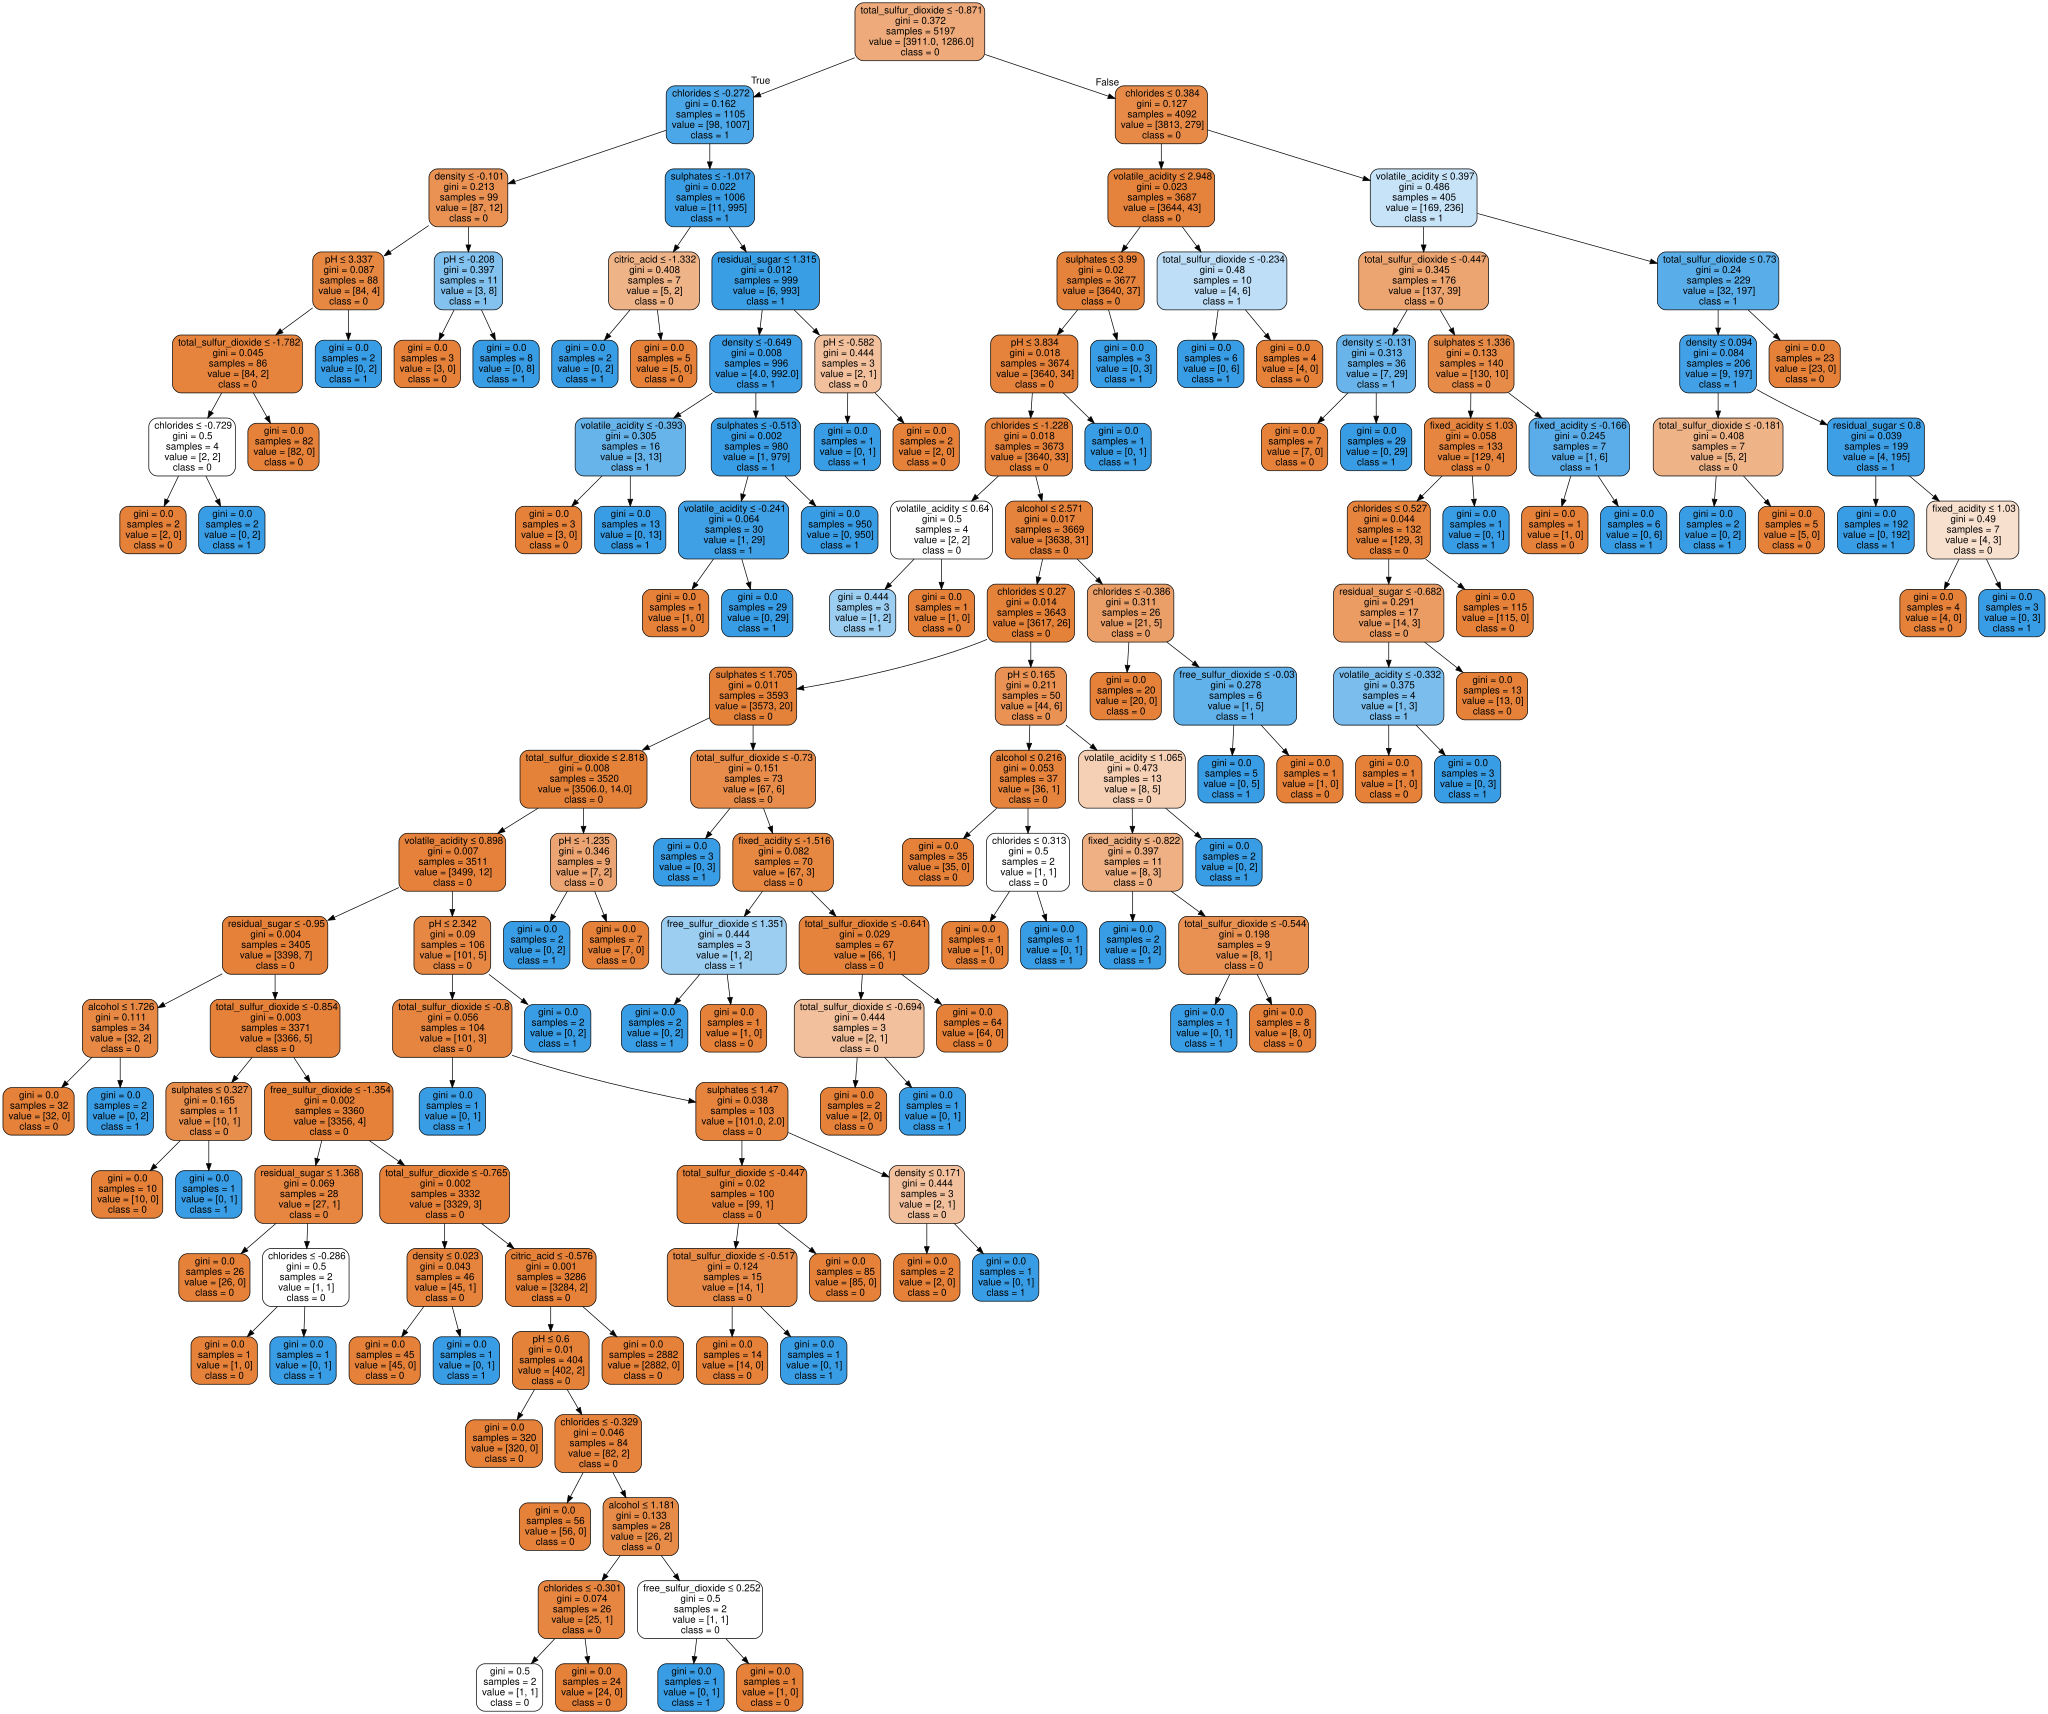

In [19]:
from sklearn.tree import export_graphviz
import graphviz

# Export the decision tree as a Graphviz file
dot_data = export_graphviz(dt_clf, out_file=None,
                           feature_names=X_train.columns,
                           class_names=['0', '1'],
                           filled=True, rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)

# Show the decision tree
graph


## Analyzing the results

In the DT we can observe the different splits(decisions) involved in classifying a sample. At every decision node, we can see the actual decision condition, the Gini index (split quality), the number of samples and values that satisfy that condition, and its class.